# Hurricane Beryl Flood Analysis

**July 7-10, 2024 | Houston, Texas**

Hurricane Beryl made landfall near Matagorda, TX on July 8, 2024 as a
Category 1 hurricane and tracked directly over the Houston metro area,
dumping 250-430 mm (10-17 in) of rain in a single day. Multiple bayous
exceeded flood stage as the storm's heaviest rain bands swept from south
to north across the city.

This notebook pulls data from three complementary sources with **cosecha**
and combines them into a multi-source flood analysis:

| Source | Reaper | What it reveals |
|--------|--------|-----------------|
| USGS Streamflow | `USGSNWISReaper` | *When* and *how severely* each channel flooded |
| MRMS Radar QPE | `MRMSReaper` | *Where* and *how much* rain actually fell |
| HRRR Forecasts | `NWPReaper` | *What models predicted* before the rain arrived |

No single data source tells the full story. Streamflow alone does not
reveal *why* some basins flooded worse than others; radar rainfall alone
does not tell us *when* channels actually overtopped; and forecasts alone
do not show what actually happened. Together, they expose the
**rainfall-runoff lag**, the **spatial rainfall pattern** that drove
sequential bayou flooding, and where the operational forecast fell short.

## Setup

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from cosecha import MRMSReaper, NWPReaper, USGSNWISReaper

# Houston bayou gages that recorded major peaks during Beryl
GAGES = {
    "08074000": "Buffalo Bayou",
    "08075000": "Brays Bayou",
    "08075770": "Hunting Bayou",
    "08074500": "Whiteoak Bayou",
}

START, END = "2024-07-07", "2024-07-10"

# Houston metro bounding box (for subsetting gridded data)
HOUSTON = {"lat_bounds": (29.4, 30.2), "lon_bounds": (-96.0, -94.8)}

IMG_DIR = Path("images")
IMG_DIR.mkdir(exist_ok=True)

## 1. Streamflow: When Did Each Bayou Flood?

Fifteen-minute instantaneous discharge (USGS parameter `00060`) shows
exactly when each bayou peaked and how the flood wave propagated across
the city.

In [2]:
nwis = USGSNWISReaper(
    site_ids=list(GAGES.keys()),
    start_date=START,
    end_date=END,
    parameter_code="00060",
)
streamflow = nwis.reap()

print(f"Records : {len(streamflow):,}")
print(f"Gages   : {streamflow['monitoring_location_id'].nunique()}")
print(f"Period  : {streamflow['time'].min()} -> {streamflow['time'].max()}")

Records : 1,155
Gages   : 4
Period  : 2024-07-07 00:00:00+00:00 -> 2024-07-10 00:00:00+00:00


### Multi-Gage Hydrograph

Plotting all four bayous on one axis reveals how the flood wave cascaded
through the Houston metro area as Beryl's rain bands moved northward.

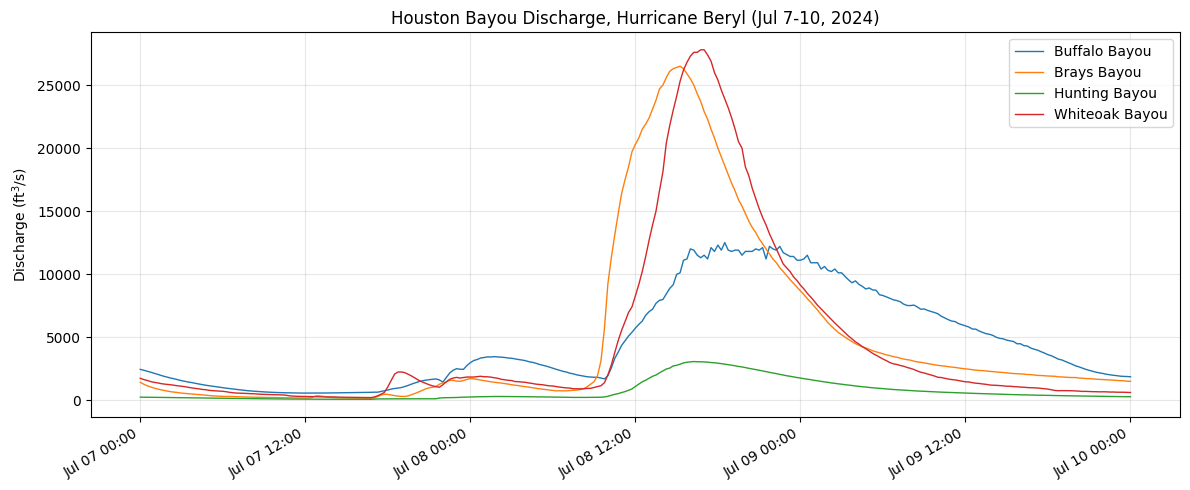

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

for site_id, name in GAGES.items():
    site = streamflow.loc[
        streamflow["monitoring_location_id"] == f"USGS-{site_id}"
    ].sort_values("time")
    ax.plot(site["time"], site["value"], label=name, linewidth=1)

ax.set_ylabel("Discharge (ft$^3$/s)")
ax.set_title("Houston Bayou Discharge, Hurricane Beryl (Jul 7-10, 2024)")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %H:%M"))
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()

The peak sequence tells the story: Brays Bayou crested first
(15:15 UTC), followed by Hunting Bayou (16:15), Whiteoak Bayou (16:45),
and finally Buffalo Bayou (18:30), the largest watershed and last to
peak. This downstream propagation of the flood wave is only visible with
multi-gage data.

## 2. Radar Precipitation: Where Did the Rain Fall?

MRMS hourly QPE at ~1 km resolution reveals the spatial rainfall pattern
that drove the sequential flooding we just saw in the streamflow data.
We focus on July 8, the day all four bayous peaked.

In [4]:
mrms = MRMSReaper(
    start_time="2024-07-08 00:00",
    end_time="2024-07-08 23:00",
    transformations={"spatial_subset": HOUSTON},
)
precip_obs = mrms.reap()

# Daily total in inches (MRMS QPE is in mm)
daily_total_in = precip_obs[mrms.variable].sum(dim="time") / 25.4
print(f"Domain max: {float(daily_total_in.max()):.1f} inches on Jul 8")

Domain max: 9.0 inches on Jul 8


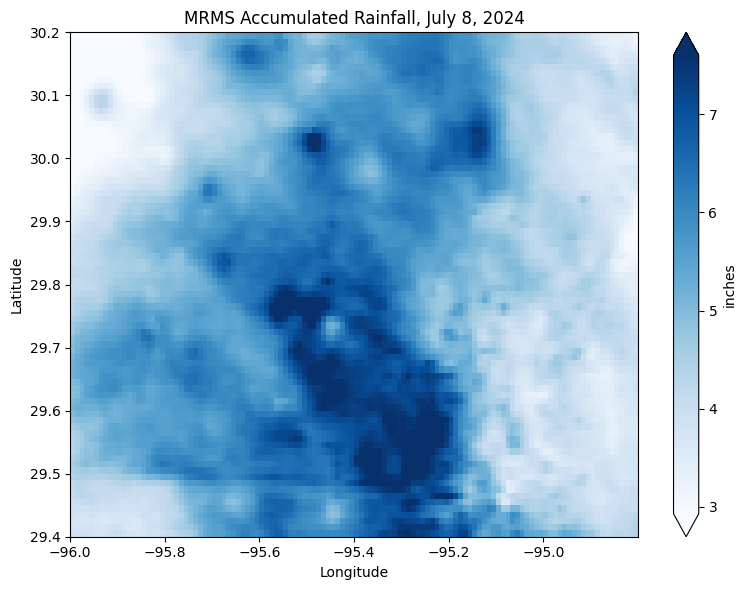

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
daily_total_in.plot(
    ax=ax, cmap="Blues", robust=True, cbar_kwargs={"label": "inches"}
)
ax.set_title("MRMS Accumulated Rainfall, July 8, 2024")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.tight_layout()

The spatial pattern makes it immediately clear which sub-basins received
the heaviest rainfall, context that a handful of rain gages alone
could never provide.

## 3. Forecast vs. Observed Precipitation

HRRR (3 km) was the highest-resolution operational forecast available
during Beryl. Comparing its predicted rainfall against MRMS observations
shows how well the model captured the track and intensity of the
hurricane's rain bands as they moved over Houston.

In [6]:
hrrr = NWPReaper(
    init_time="2024-07-08 00:00",
    model="hrrr",
    forecast_hours=range(1, 19),
    variable="hourly_precip",
    transformations={
        "spatial_subset": HOUSTON,
        "unit_conversions": {"tp": 1 / 25.4},
        "variable_rename": {"tp": "precip_in"},
    },
)
precip_fcst = hrrr.reap()

fcst_total = precip_fcst["precip_in"].sum(dim="step")
print(f"HRRR 18-h forecast max: {float(fcst_total.max()):.1f} inches")

HRRR 18-h forecast max: 9.7 inches


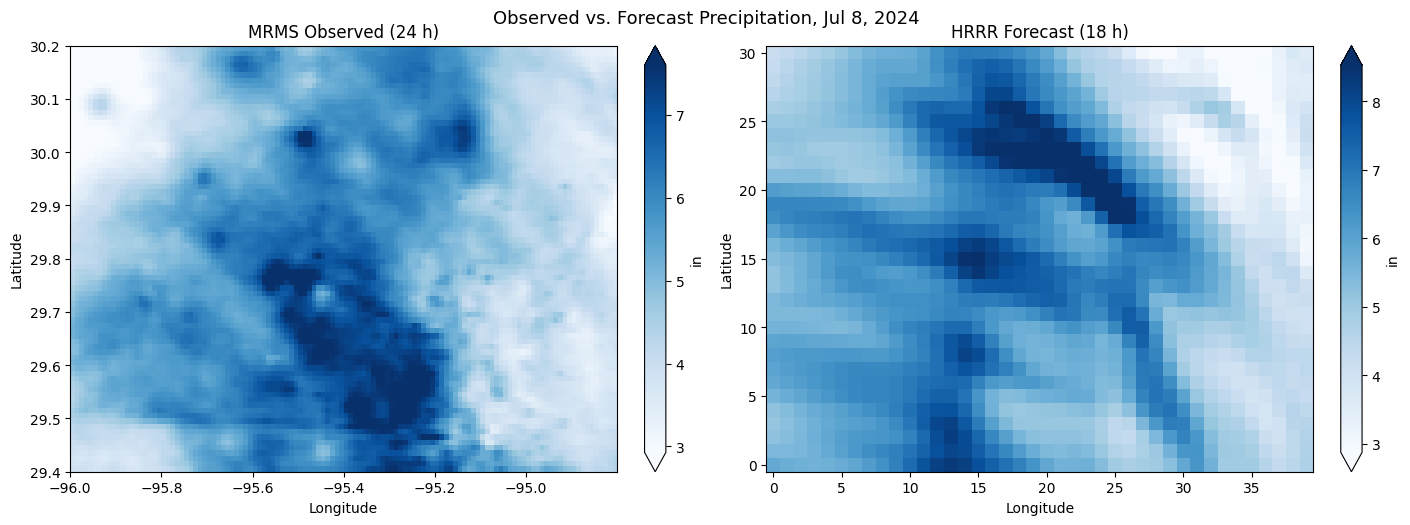

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

daily_total_in.plot(
    ax=axes[0], cmap="Blues", robust=True, cbar_kwargs={"label": "in"}
)
axes[0].set_title("MRMS Observed (24 h)")

fcst_total.plot(
    ax=axes[1], cmap="Blues", robust=True, cbar_kwargs={"label": "in"}
)
axes[1].set_title("HRRR Forecast (18 h)")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.suptitle(
    "Observed vs. Forecast Precipitation, Jul 8, 2024",
    fontsize=13,
    y=1.02,
)
fig.savefig(IMG_DIR / "beryl_obs_vs_fcst.png", dpi=150, bbox_inches="tight")

Comparing 18 forecast hours against 24 observed hours highlights where the
HRRR captured Beryl's rainfall core and where it diverged, a key
diagnostic for improving operational flood warnings during landfalling
hurricanes.

## 4. Rainfall-Runoff: Tying It Together

Plotting basin-average cumulative MRMS rainfall alongside Buffalo Bayou's
discharge reveals the **rainfall-runoff lag**, the delay between peak
rainfall intensity and peak streamflow. In Houston's highly urbanized
watersheds this lag is typically 2-4 hours, leaving very little time for
evacuation once intense rainfall begins.

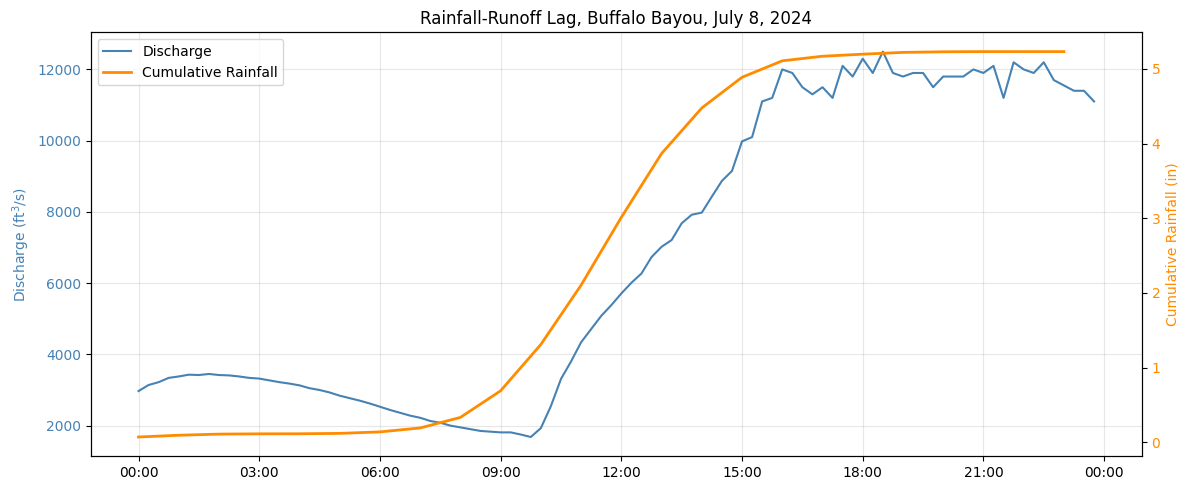

In [8]:
# Basin-average cumulative rainfall from MRMS (inches)
hourly_avg_mm = precip_obs[mrms.variable].mean(dim=["latitude", "longitude"])
cumul_in = hourly_avg_mm.cumsum(dim="time") / 25.4

# Buffalo Bayou discharge on Jul 8
buffalo = streamflow.loc[
    (streamflow["monitoring_location_id"] == "USGS-08074000")
    & (streamflow["time"].dt.date == pd.Timestamp("2024-07-08").date())
].sort_values("time")

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    buffalo["time"], buffalo["value"],
    color="steelblue", lw=1.5, label="Discharge",
)
ax1.set_ylabel("Discharge (ft$^3$/s)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(
    pd.to_datetime(cumul_in.time.values), cumul_in.values,
    color="darkorange", lw=2, label="Cumulative Rainfall",
)
ax2.set_ylabel("Cumulative Rainfall (in)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax1.set_title("Rainfall-Runoff Lag, Buffalo Bayou, July 8, 2024")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax1.grid(True, alpha=0.3)

lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper left")
fig.tight_layout()

The steepest portion of the cumulative rainfall curve precedes the
discharge peak by several hours. That gap is the basin's response time
and the maximum warning lead time available from radar observations alone.

## Summary

This analysis used cosecha's three reapers to build a complete picture of
Hurricane Beryl's flooding in Houston:

- **`USGSNWISReaper`** revealed the timing and magnitude of flooding at
  each bayou and the downstream propagation of the flood wave (Brays
  peaked first, Buffalo Bayou last).
- **`MRMSReaper`** showed the spatial rainfall pattern that explains
  *why* certain basins flooded more severely than others.
- **`NWPReaper`** compared HRRR forecast precipitation against radar
  observations, diagnosing where the operational model captured Beryl's
  rainfall and where it diverged.
- **Combining all three** exposed the rainfall-runoff lag, a critical
  parameter for flash-flood warning systems.

The flood's progression only becomes clear when you see the rainfall
*where* it fell (MRMS), compare it to what was *predicted* (HRRR), and
measure what the watershed *actually did* (USGS).